# NY Vir Newtonian N-Body Modeling
Demonstrates Newtonian N-body modeling using Rebound.

In [1]:
%load_ext autoreload
%autoreload 2
import os

In [2]:
from ocpy.data import Data

data = Data.from_file("../ny_vir_minima.xlsx")
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2453174.442769
period = 0.1010159690

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="pymc"
)

In [3]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter

nbody = NewtonianModel(
    central_mass=Parameter(value=0.611, fixed=True),
    T0_ref=t0,
    P_ref=period,
    bodies = [
        {
            "m":     Parameter(value=0.0021, fixed=False, std=1,  min=0),
            "P":     Parameter(value=3170.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.05,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=269.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2443302.0, fixed=False, std=3170.0), 
        },
        {
            "m":     Parameter(value=0.0038, fixed=False, std=1,  min=0),
            "P":     Parameter(value=8260.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.02,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=140.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2421163.0, fixed=False, std=8260.0), 
        }
    ],
    name="nbody"
)
models = [nbody]

Multiprocess sampling (12 chains in 12 jobs)
DEMetropolisZ: [nbody_b1_m, nbody_b1_P, nbody_b1_e, nbody_b1_omega, nbody_b1_T, nbody_b2_m, nbody_b2_P, nbody_b2_e, nbody_b2_omega, nbody_b2_T]


Output()

Sampling 12 chains for 3_000 tune and 5_000 draw iterations (36_000 + 60_000 draws total) took 5753 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: ylabel='O−C'>

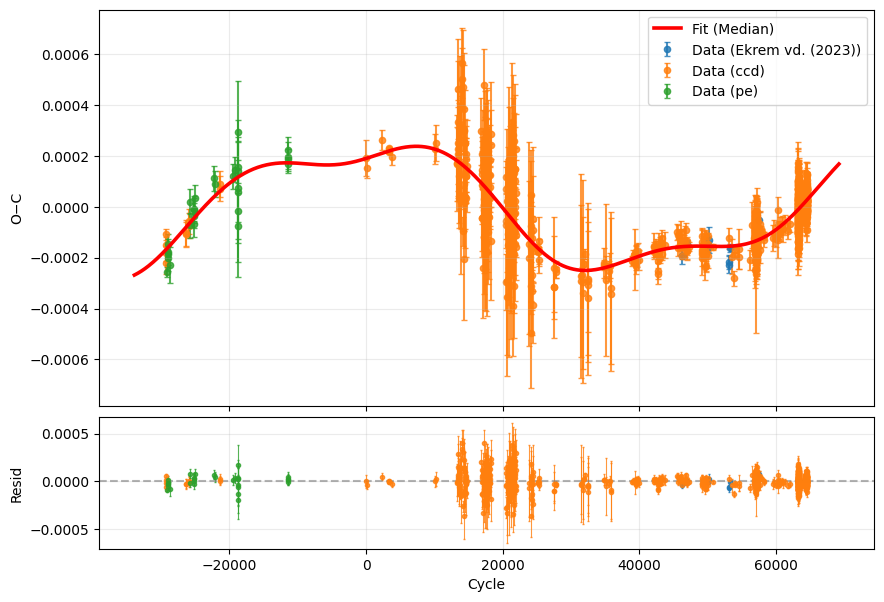

In [4]:
from pymc import DEMetropolisZ
res = oc.fit(models, tune=3000, draws=5000, chains=12)
oc.plot(res)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

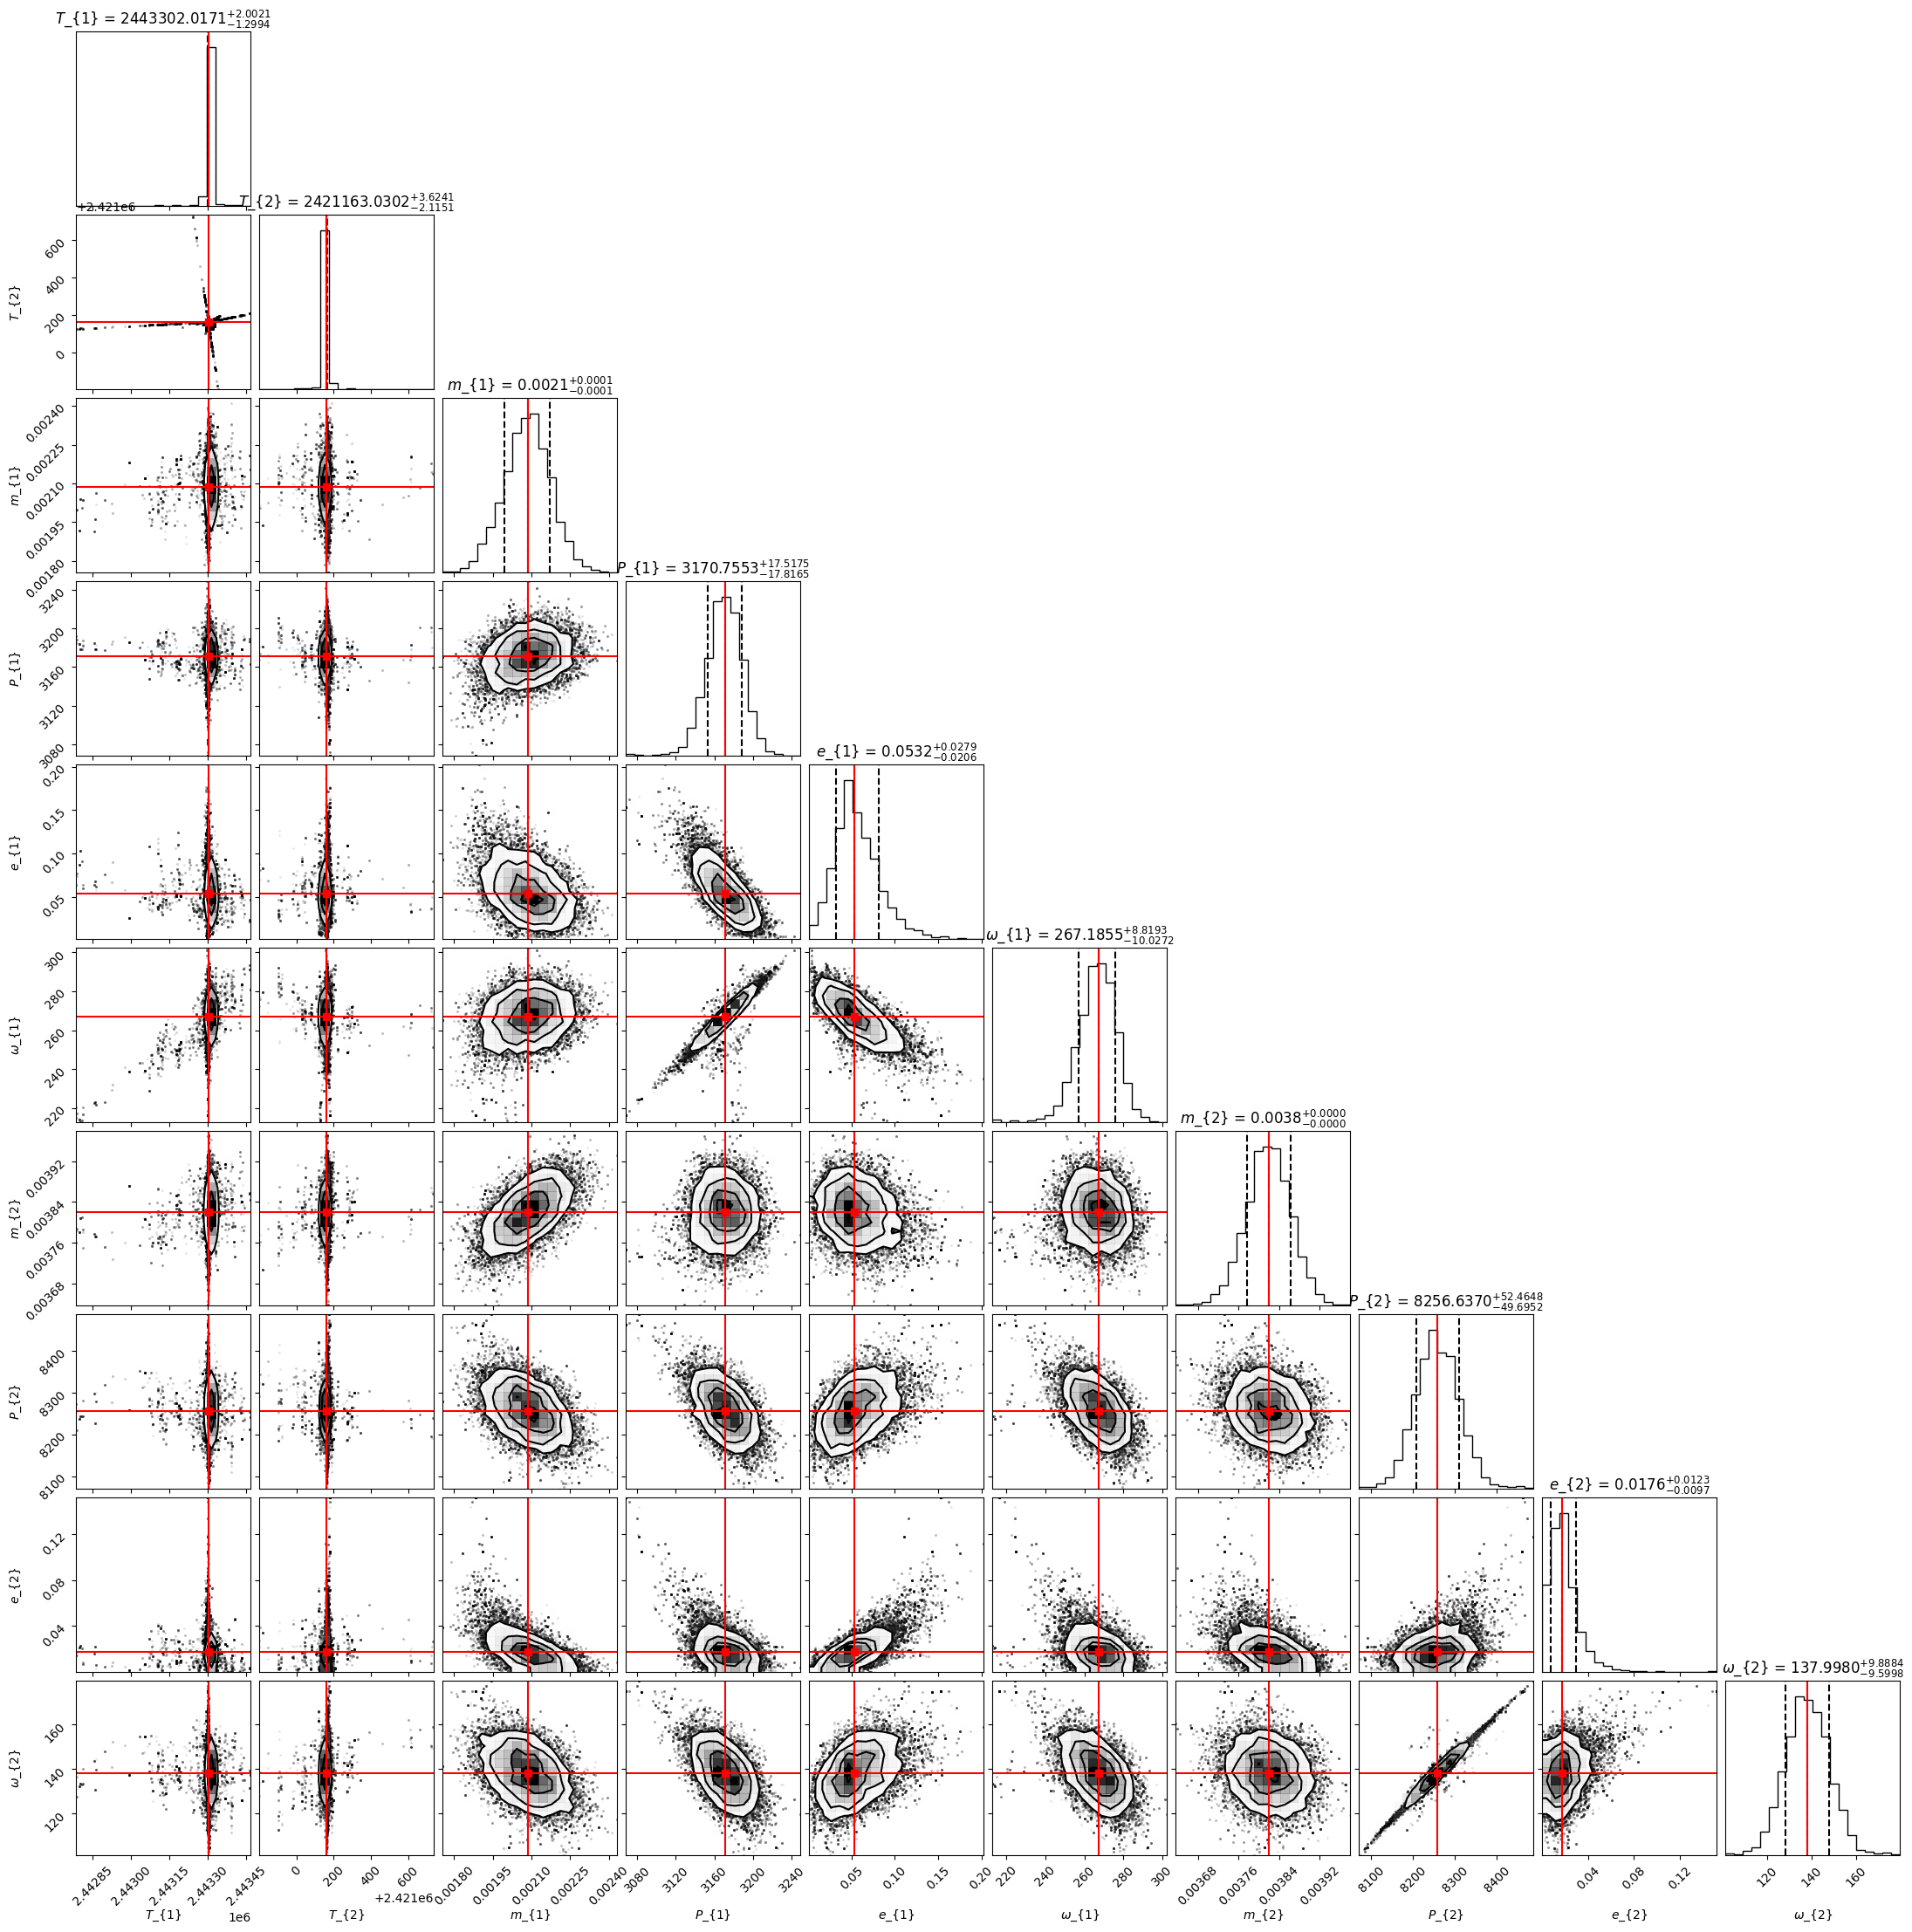

In [5]:
oc.corner(res)
res

In [6]:
cleaned_res = oc.clean(res)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

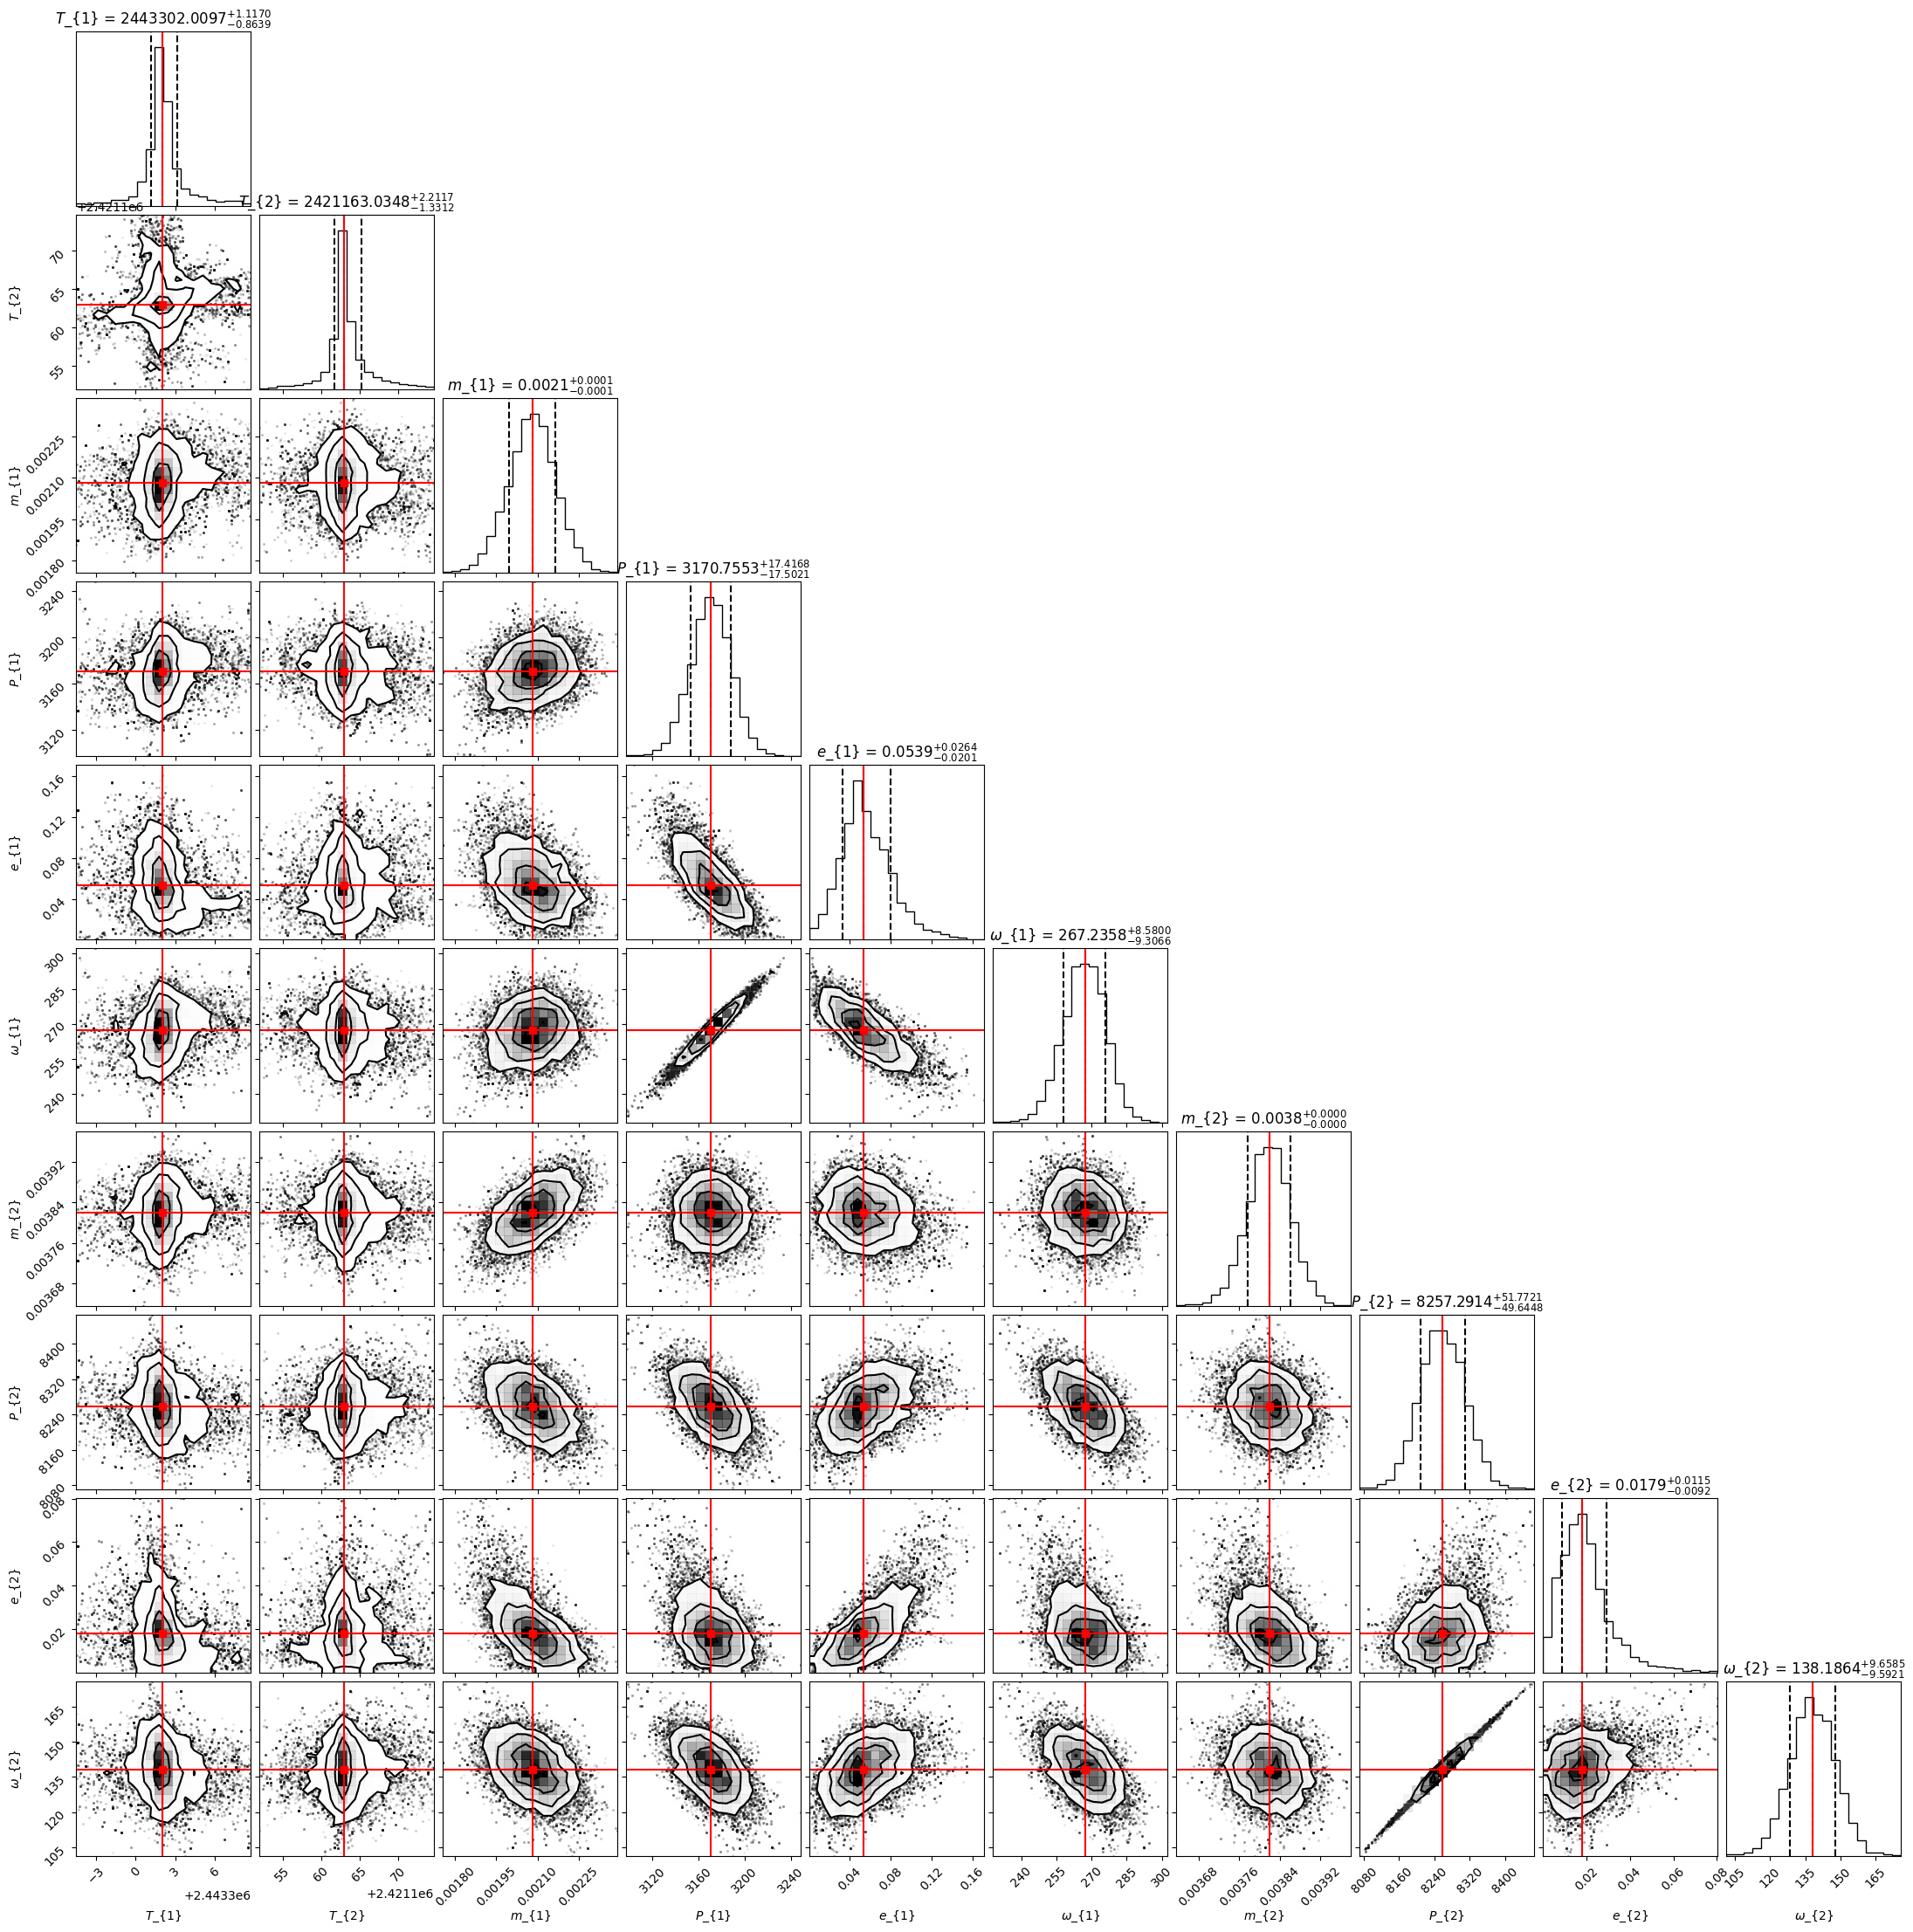

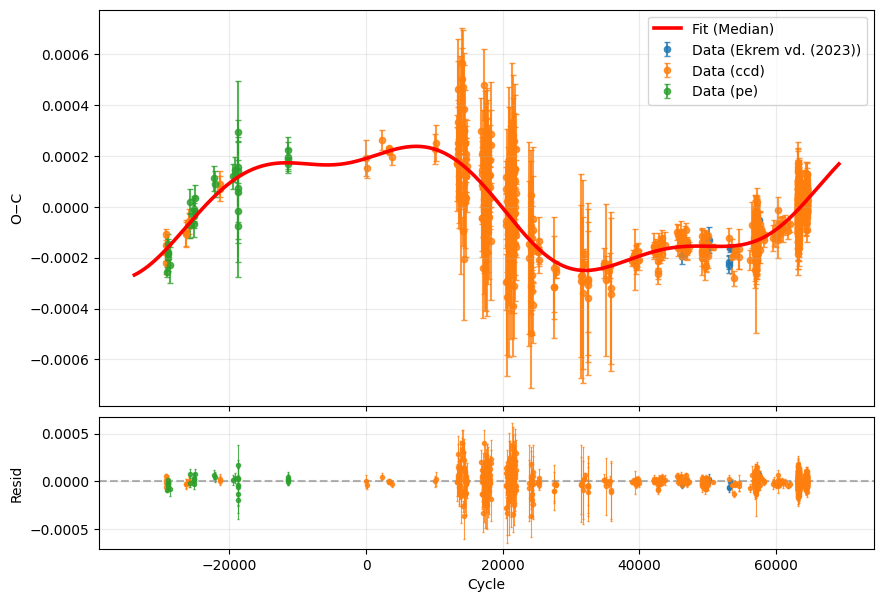

In [7]:
oc.corner(cleaned_res)
oc.plot(cleaned_res, extension_factor=0.05, model_components=models)
res

In [28]:
res.posterior.median

<bound method DatasetAggregations.median of <xarray.Dataset> Size: 474MB
Dimensions:             (chain: 12, draw: 5000, y_model_dim_0: 976)
Coordinates:
  * chain               (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw                (draw) int64 40kB 0 1 2 3 4 ... 4995 4996 4997 4998 4999
  * y_model_dim_0       (y_model_dim_0) int64 8kB 0 1 2 3 4 ... 972 973 974 975
Data variables:
    nbody_b1_T          (chain, draw) float64 480kB 2.443e+06 ... 2.443e+06
    nbody_b2_T          (chain, draw) float64 480kB 2.421e+06 ... 2.421e+06
    nbody_b1_m          (chain, draw) float64 480kB 0.00197 0.00197 ... 0.002082
    nbody_b1_P          (chain, draw) float64 480kB 3.169e+03 ... 3.152e+03
    nbody_b1_e          (chain, draw) float64 480kB 0.08188 0.08188 ... 0.06443
    nbody_b1_omega      (chain, draw) float64 480kB 264.4 264.4 ... 247.1 247.1
    nbody_b2_m          (chain, draw) float64 480kB 0.003826 ... 0.003816
    nbody_b2_P          (chain, draw) float64 480kB 8.294e

In [29]:
from ocpy.orbital_params import compute_orbital_params_from_fit
result = compute_orbital_params_from_fit(res, ref_period=0.101, m1=0.471, m2=0.14)
result

Parameter,Value,Uncertainty,Unit
amp,7.0510e-05,+2.9308e−06 / −3.1996e−06,day
amp,6.092053,+0.253224 / −0.276446,s
e,0.053232,+0.027903 / −0.020580,
omega,267.185469,+8.819333 / −10.027194,deg
omega,4.663266,+0.153926 / −0.175008,rad
T_0,2.4433e+06,+2.0021e+00 / −1.2994e+00,BJD
P,3170.755274,+17.517534 / −17.816465,day
P,8.681240,+0.047961 / −0.048780,yr
a_{12} sin i,0.012209,+0.000507 / −0.000553,AU
a_{12} sin i,2.625412,+0.109050 / −0.119004,R_sun


In [16]:
result.latex

'% nbody_b1\n\\begin{table}\n    \\centering\n    \\begin{tabular}{lcc}\n        \\hline\n        Parameter & Value & Unit \\\\\n        \\hline\n        $A$ & $7.0510 \\times 10^{-5}^{+2.9308 \\times 10^{-6}}_{-3.1996 \\times 10^{-6}}$ & $\\mathrm{d}$ \\\\\n        $A$ & $6.0921^{+0.2532}_{-0.2764}$ & $\\mathrm{s}$ \\\\\n        $e$ & $0.0532^{+0.0279}_{-0.0206}$ & \\\\\n        $\\omega$ & $267.1855^{+8.8193}_{-10.0272}$ & $^{\\circ}$ \\\\\n        $\\omega$ & $4.6633^{+0.1539}_{-0.1750}$ & $\\mathrm{rad}$ \\\\\n        $P$ & $3170.7553^{+17.5175}_{-17.8165}$ & $\\mathrm{d}$ \\\\\n        $P$ & $8.6812^{+0.0480}_{-0.0488}$ & $\\mathrm{yr}$ \\\\\n        $a_{12}\\,\\sin i$ & $0.0122^{+5.0713 \\times 10^{-4}}_{-5.5343 \\times 10^{-4}}$ & $\\mathrm{AU}$ \\\\\n        $a_{12}\\,\\sin i$ & $2.6254^{+0.1090}_{-0.1190}$ & $R_{\\odot}$ \\\\\n        $f(m_3)$ & $2.4142 \\times 10^{-8}^{+3.0668 \\times 10^{-9}}_{-3.0364 \\times 10^{-9}}$ & $M_{\\odot}$ \\\\\n        $m_3\\,\\sin i$ & $2.0858 \\times 10^{-3}^{+8.5025 \\times 10^{-5}}_{-9.1591 \\times 10^{-5}}$ & $M_{\\odot}$ \\\\\n        $m_3\\,\\sin i$ & $2.1850^{+0.0891}_{-0.0959}$ & $M_{\\mathrm{Jup}}$ \\\\\n        $m_3\\,\\sin i$ & $694.4577^{+28.3089}_{-30.4947}$ & $M_{\\oplus}$ \\\\\n        $a_3\\,\\sin i$ & $3.5883^{+0.0132}_{-0.0134}$ & $\\mathrm{AU}$ \\\\\n        \\hline\n    \\end{tabular}\n\\end{table}\n\n% nbody_b2\n\\begin{table}\n    \\centering\n    \\begin{tabular}{lcc}\n        \\hline\n        Parameter & Value & Unit \\\\\n        \\hline\n        $A$ & $2.4393 \\times 10^{-4}^{+2.6541 \\times 10^{-6}}_{-2.7717 \\times 10^{-6}}$ & $\\mathrm{d}$ \\\\\n        $A$ & $21.0754^{+0.2293}_{-0.2395}$ & $\\mathrm{s}$ \\\\\n        $e$ & $0.0176^{+0.0123}_{-9.6651 \\times 10^{-3}}$ & \\\\\n        $\\omega$ & $137.9980^{+9.8884}_{-9.5998}$ & $^{\\circ}$ \\\\\n        $\\omega$ & $2.4085^{+0.1726}_{-0.1675}$ & $\\mathrm{rad}$ \\\\\n        $P$ & $8256.6370^{+52.4648}_{-49.6952}$ & $\\mathrm{d}$ \\\\\n        $P$ & $22.6059^{+0.1436}_{-0.1361}$ & $\\mathrm{yr}$ \\\\\n        $a_{12}\\,\\sin i$ & $0.0422^{+4.5750 \\times 10^{-4}}_{-4.7009 \\times 10^{-4}}$ & $\\mathrm{AU}$ \\\\\n        $a_{12}\\,\\sin i$ & $9.0833^{+0.0984}_{-0.1011}$ & $R_{\\odot}$ \\\\\n        $f(m_3)$ & $1.4743 \\times 10^{-7}^{+5.0056 \\times 10^{-9}}_{-4.9150 \\times 10^{-9}}$ & $M_{\\odot}$ \\\\\n        $m_3\\,\\sin i$ & $3.8197 \\times 10^{-3}^{+4.2929 \\times 10^{-5}}_{-4.3104 \\times 10^{-5}}$ & $M_{\\odot}$ \\\\\n        $m_3\\,\\sin i$ & $4.0014^{+0.0450}_{-0.0452}$ & $M_{\\mathrm{Jup}}$ \\\\\n        $m_3\\,\\sin i$ & $1271.7471^{+14.2930}_{-14.3512}$ & $M_{\\oplus}$ \\\\\n        $a_3\\,\\sin i$ & $6.7983^{+0.0287}_{-0.0272}$ & $\\mathrm{AU}$ \\\\\n        \\hline\n    \\end{tabular}\n\\end{table}'